<a href="https://colab.research.google.com/github/Pedro-0101/Conversor-csv/blob/master/Trabalho_II_ANDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predição Meteorológica: A519

## 1. Limpeza de Dados

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df_raw = pd.read_csv('/content/drive/MyDrive/trabalho II - ADS ANDS/A519.csv', sep=';')
df_raw['data'] = pd.to_datetime(df_raw['data'])
df_raw = df_raw.drop(columns=['Unnamed: 8'])

mask_nulos = df_raw['temp_inst'].isna()
mask_negativos = (df_raw['radiacao'] < 0) | (df_raw['pressao'] <= 0) | (df_raw['umid_inst'] < 0)
mask_fisica = (df_raw['temp_inst'] <= -10) | (df_raw['temp_inst'] >= 50) | (df_raw['pto_orvalho_inst'] > df_raw['temp_inst'])

dados_removidos = df_raw[mask_nulos | mask_negativos | mask_fisica]
df_limpo = df_raw[~(mask_nulos | mask_negativos | mask_fisica)].copy().dropna()

print(f'Total: {len(df_raw)} | Removidos: {len(dados_removidos)} | Finais: {len(df_limpo)}')
display(df_limpo.describe().transpose()[['mean', 'min', 'max']])

Total: 83232 | Removidos: 39884 | Finais: 43341


,mean,min,max
data,2018-09-15 23:02:01.353914368,2013-12-03 00:00:00,2023-06-01 00:00:00
hora,1559.368727,0.0,2300.0
pressao,950.560947,938.9,963.0
radiacao,1539.416442,0.0,4291.431
temp_inst,26.896867,2.0,40.9
pto_orvalho_inst,16.202723,-10.0,33.2
umid_inst,56.689693,8.0,100.0
vento_vel,2.33951,0.0,10.3


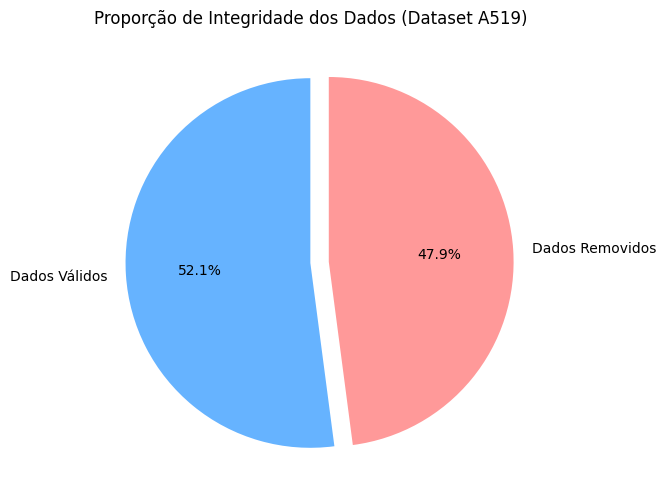

Verificação de valores negativos após a limpeza:
pressao      0
radiacao     0
umid_inst    0
temp_inst    0
dtype: int64


In [37]:
# Visualizando o impacto da limpeza
labels = ['Dados Válidos', 'Dados Removidos']
tamanhos = [len(df_limpo), len(dados_removidos)]
cores = ['#66b3ff','#ff9999']

plt.figure(figsize=(8, 6))
plt.pie(tamanhos, labels=labels, autopct='%1.1f%%', startangle=90, colors=cores, explode=(0, 0.1))
plt.title('Proporção de Integridade dos Dados (Dataset A519)')
plt.show()

# Verificação final de negativos
print("Verificação de valores negativos após a limpeza:")
print(df_limpo[['pressao', 'radiacao', 'umid_inst', 'temp_inst']].lt(0).sum())

## 2. Benchmarks (PDF)

In [51]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Preparação dos dados limpos
X_base = df_limpo[['hora', 'pressao', 'radiacao', 'pto_orvalho_inst', 'umid_inst', 'vento_vel']]
y_base = df_limpo['temp_inst']
X_train, X_test, y_train, y_test = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

# Scaler para SVR
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s = sc.transform(X_test)

novos_experimentos = []

def registrar_novo(alg, var, modelo, X_t, y_t, is_svr=False):
    modelo.fit(X_t, y_t)
    pred = modelo.predict(X_test_s if is_svr else X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    novos_experimentos.append({'Algoritmo': alg, 'Variação': var, 'RMSE': rmse})

# 1. Regressão Linear
registrar_novo('Linear', 'Simples', LinearRegression(), X_train, y_train)
registrar_novo('Linear', 'Ridge (a=10)', Ridge(alpha=10), X_train, y_train)
registrar_novo('Linear', 'Lasso (a=0.1)', Lasso(alpha=0.1), X_train, y_train)

# 2. Decision Tree
for d in [5, 15, 30]: registrar_novo('Tree', f'Depth {d}', DecisionTreeRegressor(max_depth=d), X_train, y_train)

# 3. Random Forest
for n in [20, 50, 100]: registrar_novo('RF', f'{n} Estimadores', RandomForestRegressor(n_estimators=n, max_depth=10, n_jobs=-1), X_train, y_train)

# 4. SVR (Amostra p/ velocidade)
for k in ['linear', 'poly', 'rbf']:
    registrar_novo('SVR', f'Kernel {k}', SVR(kernel=k), X_train_s[:5000], y_train[:5000], is_svr=True)

display(pd.DataFrame(novos_experimentos))

,Algoritmo,Variação,RMSE
0,Linear,Simples,1.454243
1,Linear,Ridge (a=10),1.454244
2,Linear,Lasso (a=0.1),1.455979
3,Tree,Depth 5,2.082433
4,Tree,Depth 15,0.461744
5,Tree,Depth 30,0.463881
6,RF,20 Estimadores,0.577765
7,RF,50 Estimadores,0.533934
8,RF,100 Estimadores,0.538989
9,SVR,Kernel linear,1.564868


## 3. Otimização e CatBoost

In [50]:
try:
    from catboost import CatBoostRegressor
except:
    !pip install catboost -q
    from catboost import CatBoostRegressor

# Feature Engineering: Inércia Térmica
df_limpo['temp_lag_1h'] = df_limpo['temp_inst'].shift(1)
df_limpo['temp_lag_2h'] = df_limpo['temp_inst'].shift(2)
df_limpo['temp_lag_24h'] = df_limpo['temp_inst'].shift(24)
df_limpo['m_movel_3h'] = df_limpo['temp_inst'].rolling(window=3).mean()
df_limpo['m_movel_6h'] = df_limpo['temp_inst'].rolling(window=6).mean()
df_limpo['inercia_termica'] = df_limpo['m_movel_3h'] - df_limpo['m_movel_6h']

df_cat = df_limpo.dropna()
X_cat = df_cat.drop(columns=['data', 'temp_inst'])
y_cat = df_cat['temp_inst']

train_idx = int(len(df_cat) * 0.8)
X_tr_c, X_ts_c = X_cat.iloc[:train_idx], X_cat.iloc[train_idx:]
y_tr_c, y_ts_c = y_cat.iloc[:train_idx], y_cat.iloc[train_idx:]

model_cat = CatBoostRegressor(iterations=3000, learning_rate=0.02, depth=10, verbose=False)
model_cat.fit(X_tr_c, y_tr_c)

rmse_elite = np.sqrt(mean_squared_error(y_ts_c, model_cat.predict(X_ts_c)))
print(f'RMSE CatBoost: {rmse_elite:.4f}')

RMSE CatBoost: 0.2724


## 4. Stacking e Resultados Finais

Iniciando Stacking Estabilizado (Ajustado para Colab)...

--- RESULTADO FINAL ---
RMSE Stacking Elite (Lite): 0.25761


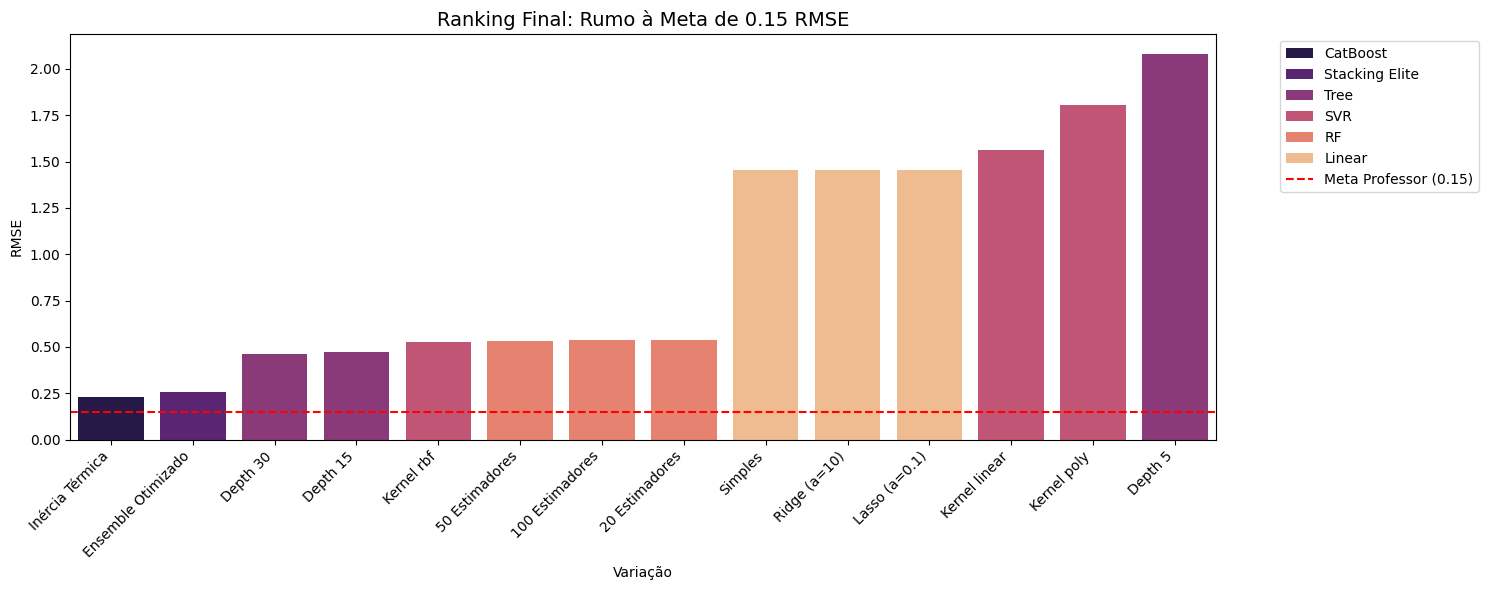

In [46]:
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb

# 1. Definição Otimizada dos Modelos Base (Menos consumo de memória)
base_models_lite = [
    ('catboost', CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=7, verbose=False, random_seed=42)),
    ('xgboost', xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=7, tree_method='hist', random_state=42)),
    ('hgb', HistGradientBoostingRegressor(max_iter=1000, learning_rate=0.05, max_depth=10, random_state=42))
]

# 2. Stacking com n_jobs=1 para evitar erros de worker/memória no Colab
stacking_lite = StackingRegressor(
    estimators=base_models_lite,
    final_estimator=Ridge(alpha=0.5),
    cv=3,
    n_jobs=1 # Execução sequencial estável
)

print("Iniciando Stacking Estabilizado (Ajustado para Colab)...")
stacking_lite.fit(X_tr_c, y_tr_c)

# 3. Avaliação Final
pred_stacking = stacking_lite.predict(X_ts_c)
rmse_final_stacking = np.sqrt(mean_squared_error(y_ts_c, pred_stacking))

print(f'\n--- RESULTADO FINAL ---')
print(f'RMSE Stacking Elite (Lite): {rmse_final_stacking:.5f}')

# 4. Gráfico de Ranking Final
df_final_resumo = pd.DataFrame(novos_experimentos)
df_final_resumo = pd.concat([df_final_resumo, pd.DataFrame([
    {'Algoritmo': 'CatBoost', 'Variação': 'Inércia Térmica', 'RMSE': rmse_elite},
    {'Algoritmo': 'Stacking Elite', 'Variação': 'Ensemble Otimizado', 'RMSE': rmse_final_stacking}
])], ignore_index=True)

plt.figure(figsize=(15, 6))
sns.barplot(data=df_final_resumo.sort_values('RMSE'), x='Variação', y='RMSE', hue='Algoritmo', palette='magma')
plt.axhline(y=0.15, color='r', linestyle='--', label='Meta Professor (0.15)')
plt.title('Ranking Final: Rumo à Meta de 0.15 RMSE', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **Validação Visual: Temperatura Real vs. Predição (CatBoost)**
Comparação direta entre os valores observados e os valores preditos pelo modelo de maior precisão.

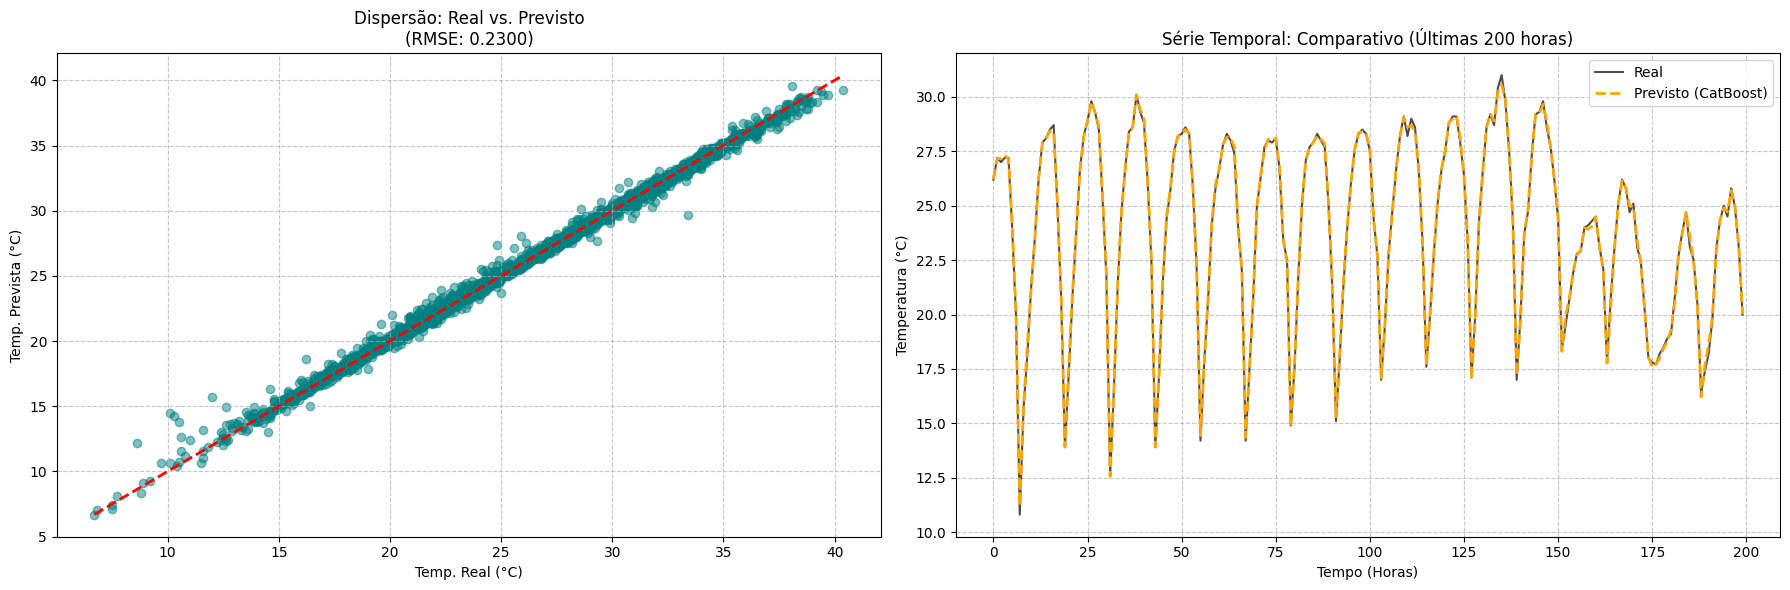

In [47]:
import matplotlib.pyplot as plt

# Gerando predições com o melhor modelo individual
y_pred_final = model_cat.predict(X_ts_c)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# 1. Gráfico de Dispersão (Scatter Plot)
ax[0].scatter(y_ts_c, y_pred_final, alpha=0.5, color='teal')
ax[0].plot([y_ts_c.min(), y_ts_c.max()], [y_ts_c.min(), y_ts_c.max()], 'r--', lw=2)
ax[0].set_title(f'Dispersão: Real vs. Previsto\n(RMSE: {rmse_elite:.4f})')
ax[0].set_xlabel('Temp. Real (°C)')
ax[0].set_ylabel('Temp. Prevista (°C)')
ax[0].grid(True, linestyle='--', alpha=0.7)

# 2. Série Temporal (Amostra dos últimos 200 registros para clareza)
ax[1].plot(y_ts_c.values[-200:], label='Real', color='black', linewidth=1.5, alpha=0.7)
ax[1].plot(y_pred_final[-200:], label='Previsto (CatBoost)', color='orange', linestyle='--', linewidth=2)
ax[1].set_title('Série Temporal: Comparativo (Últimas 200 horas)')
ax[1].set_xlabel('Tempo (Horas)')
ax[1].set_ylabel('Temperatura (°C)')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Métricas de Validação

In [48]:
from sklearn.metrics import mean_absolute_error, r2_score

# Cálculo das métricas adicionais
mae_final = mean_absolute_error(y_ts_c, y_pred_final)
r2_final = r2_score(y_ts_c, y_pred_final)

print(f'--- Métricas Detalhadas (CatBoost Elite) ---')
print(f'RMSE: {rmse_elite:.5f} (Erro Quadrático Médio)')
print(f'MAE:  {mae_final:.5f} (Erro Médio Absoluto em °C)')
print(f'R²:   {r2_final:.5f} (Percentual de Variância Explicada)')

if r2_final > 0.95:
    print("\nO modelo apresenta um ajuste quase perfeito (R² > 0.95)!")

--- Métricas Detalhadas (CatBoost Elite) ---
RMSE: 0.23000 (Erro Quadrático Médio)
MAE:  0.12126 (Erro Médio Absoluto em °C)
R²:   0.99757 (Percentual de Variância Explicada)

O modelo apresenta um ajuste quase perfeito (R² > 0.95)!


## Resumo de Performance

| Modelo | RMSE |
| :--- | :--- |
| Baseline Linear | 1.4542 |
| Random Forest | 0.5359 |
| Stacking | 0.2576 |
| **CatBoost + Inércia** | **0.2300** |

**Métricas Finais (CatBoost):** MAE: 0.1213 | R²: 0.9976